# Analysis of empirical CDF for covariance data calibration 

# Checklist

1. [ ] Generate better ground truth solutions for individual patch params
2. [x] Perform alignment and micropatch distribution
3. [x] Generate probability distribution for each patch using softmax
4. [x] For each patch - determine P_i
5. [x] Calculate P_GT from P_i
6. [x] Plot P_GT vs eCDF of P_GT

In [1]:
import numpy as np 
import cv2
import pickle
from matplotlib.patches import Ellipse
import pandas as pd
from scipy.stats import norm, multivariate_normal

from groundNAV_agent import *
from microp_distb import *
from distb_plotting_utils import *


# SAVE YOUR WORK
%load_ext autoreload
%autoreload 2
%autosave 180

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Autosaving every 180 seconds


### Geometric Reprojection Loss

$$
\min_{\mathbf{P}_i,\,\mathbf{X}_j}
\sum_{i,j \in \mathcal{O}}
\left\|
\mathbf{x}_{ij}
-
\pi(\mathbf{P}_i, \mathbf{X}_j)
\right\|^2
$$

where $\mathbf{x}_{ij}$ denotes the observed 2D feature location of point $\mathbf{X}_j$ in image $i$, $\mathbf{P}_i$ is the camera pose, $\pi(\cdot)$ is the projection function, and $\mathcal{O}$ is the set of observed feature correspondences.

---

### Photometric Loss

$$
\mathcal{L}_{\text{photo}}
=
\sum_{\mathbf{u}\in\Omega}
\left(
I_1(\mathbf{u})
-
I_2\!\left(\mathbf{w}(\mathbf{u}; \mathbf{P})\right)
\right)^2
$$

where $I_1$ and $I_2$ are image intensities, $\mathbf{u}$ denotes pixel coordinates over the image domain $\Omega$, and $\mathbf{w}(\mathbf{u}; \mathbf{P})$ is the warp induced by the estimated camera pose (and scene geometry).

In [2]:
# SfM files 
images_colm = '../TurfData/SfM_soln/images.txt'
cameras_colm = '../TurfData/SfM_soln/cameras.txt'
pts3d_colm = '../TurfData/SfM_soln/points3D_f.txt'

# Local images - folder
im_local = '../TurfData/local_imgs_10' # With 10 local images 
# im_local = '../TurfData/local_imgs_5' # With 5 local images

# Satellite reference image
sat_ref = '../TurfData/TurfSat.jpg'

In [3]:
# Create class 
gnav = gNAV_agent(images_colm, cameras_colm, pts3d_colm, im_local, sat_ref)

## 1. Implement pose estimations and ground truth solutions 

In [4]:
# Set ref frame - transform to ground-parallel coordinate frame
tform_ref_frame = gnav.set_ref_frame(gnav.pts_gnd_idx)
tform_ref_frame_pts = gnav.inv_homog_transform(tform_ref_frame)
print("Reference frame transformation \n", tform_ref_frame_pts)

Reference frame transformation 
 [[-1.55069060e-03  9.81197008e-01  1.93002661e-01 -1.21025836e-01]
 [-1.42845166e-01 -1.91240997e-01  9.71093270e-01  1.86102525e+00]
 [ 9.89743833e-01 -2.60636319e-02  1.40455805e-01  7.28134156e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


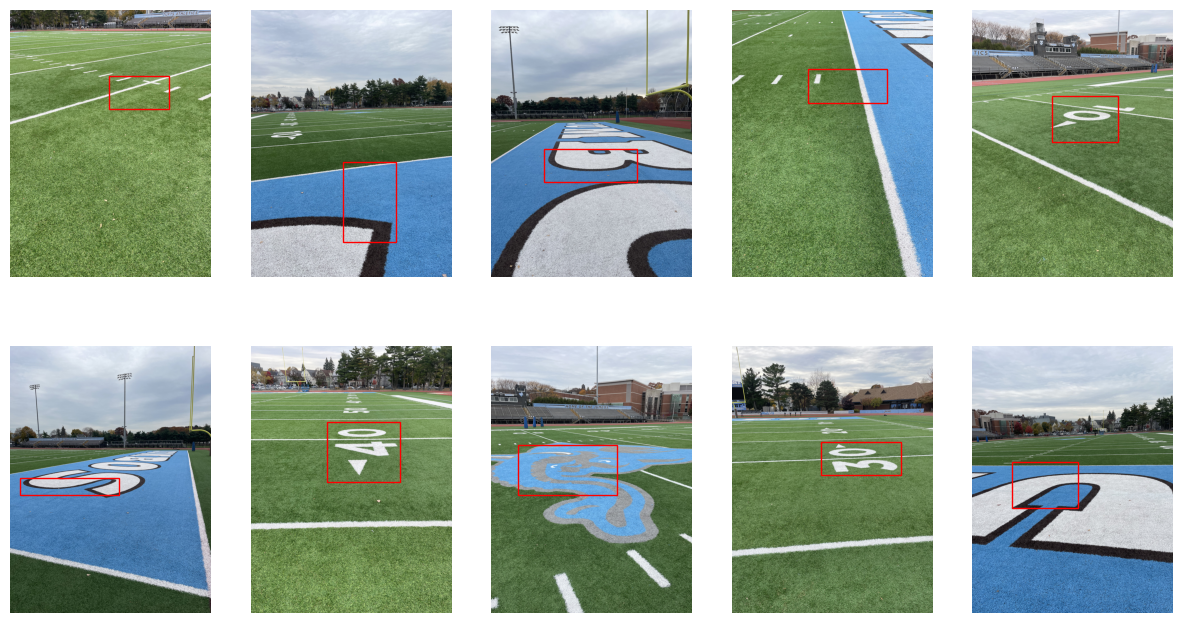

In [5]:
# Import mosaic parameters - arbitrarily obtained, can be modified
mosaic_params = np.load('../TurfData/GP_sections/mosaic_params.npy')
# Grab specified image points from local images 
gnav.grab_image_pts_tot(mosaic_params)

plt.figure(figsize=(15,8))
gnav.plot_gnd_pts()

In [6]:
# Generate projection of image sections 
for i in range(len(gnav.images_dict)):
    # STEP 1: Unit vectors in camera coords 
    pts_vec_c, pts_rgb_gnd = gnav.unit_vec_c(i)
    gnav.im_mosaic[i] = {'rgbc': pts_rgb_gnd}

    # STEP 2: Transformation matrix moves from camera coords to world coords
    id = gnav.im_ids[i]
    homog_w2c, homog_c2w = gnav.get_pose_id(id,i)
    # print('Homogeneous transformation from world to camera \n', homog_c2w)
    # print('\n Homogeneous transformation from camera to world \n', homog_w2c)

    # STEP 3: Transform to world coords
    origin_c, pts_loc_w, pts_vec_w = gnav.unit_vec_tform(pts_vec_c, gnav.origin_w, homog_c2w)
    # print('\n New camera frame origin = ', origin_c)
    
    # STEP 4: Get new points 
    ranges, new_pts_w = gnav.pt_range(pts_vec_w, homog_c2w, origin_c, i)
    # print('\nNew Points \n', new_pts_w)

    # STEP 5: Transfer points to reference frame
    __, new_pts_r, pts_vec_r = gnav.unit_vec_tform(new_pts_w, gnav.origin_w, tform_ref_frame_pts)

    # Convert points to grayscale 
    gray_c = gnav.conv_to_gray(gnav.im_mosaic[i]['rgbc'],i)
    # print(gray_c)

    # Put new points and grayscale colors in image mosaic
    gnav.im_mosaic[i]['pts'] = new_pts_r
    gnav.im_mosaic[i]['color_g'] = gray_c
    
    print("\nDone image ", i)


Done image  0

Done image  1

Done image  2

Done image  3

Done image  4

Done image  5

Done image  6

Done image  7

Done image  8

Done image  9


In [7]:
# IMPLEMENTING 'TRUTH SOLUTION' 

ind_params = np.load("../../s2/TerrainNav/ind_params.npy")
# print(ind_params)

gnav.ind_params_truth = ind_params
gnav.implement_guess_ind(gnav.ind_params_truth)

# IF NOT USING TRUTH - use converged solution (junk)
# # Initial guess parameters 
# # 5 image solution
# scale, yaw, x_g, y_g = 80, np.deg2rad(140), -52, 20
# # BEST after CONVERGENCE
# scale = 80.14819958
# yaw = 2.44777939
# x_g = -55.46495001
# y_g = 21.62910054

# tform_guess = gnav.tform_create(x_g,y_g,0,0,0,yaw)
# gnav.best_guess_tform = tform_guess
# gnav.best_guess_scale = scale

# # Implement
# gnav.implement_guess(gnav.best_guess_tform, gnav.best_guess_scale)

In [8]:
# Create visualization
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Image mosaic with reference map (initial guess)")

gnav.mosaic_w_ref_visualization(vis)

## 2. Divide each patch into micropatches 

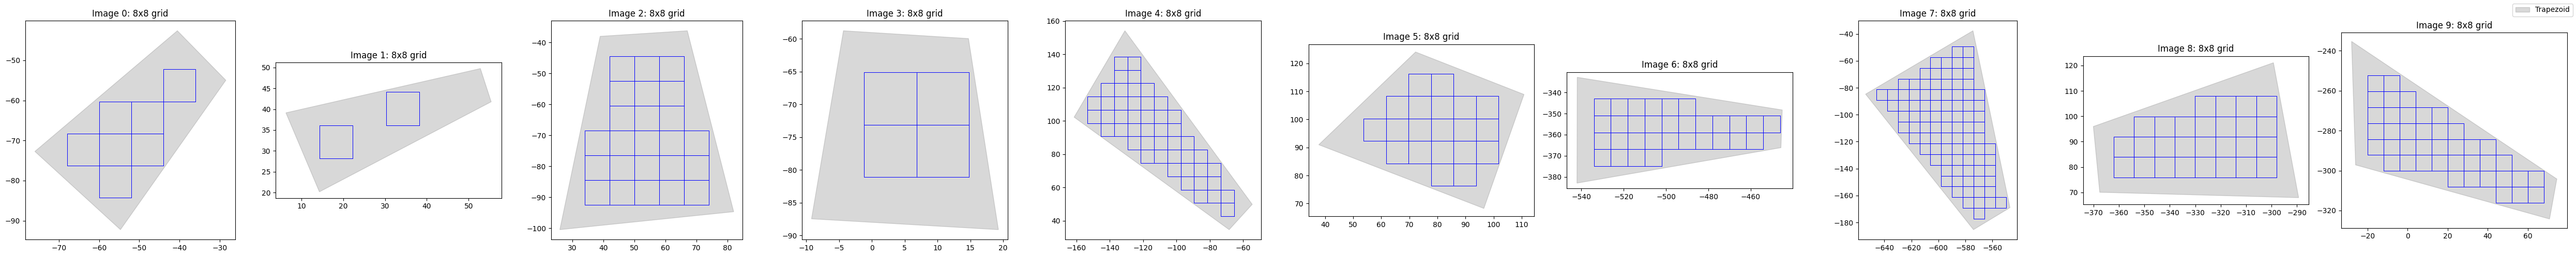

In [9]:
n = 8
micro_ps = gnav.micropatch_division(n)
gnav.micro_ps_local = copy.deepcopy(gnav.micro_ps) # KEEPING ORIGINAL, LOCAL IS WHAT WE EDIT
gnav.plot_traps_w_microps(n)

In [10]:
# VISUAL CHECK OF MICROPATCHES
# Check that the points are at least proper

# PLOTTING THE NEW SCENE MOSAIC

# Use open3d to create point cloud visualization 
# Create visualization 
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Mosaic scene with satellite reference")

# Create axes @ origin
axis_origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=10)
# vis.add_geometry(axis_origin)

# Add image patches
# for i in range(len(gnav.images_dict)):
# for i in range(2):
#     cloud = o3d.geometry.PointCloud()
#     cloud.points = o3d.utility.Vector3dVector(gnav.im_pts_best_guess[i]['pts'])
#     cloud.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[i]['color_g'])
#     vis.add_geometry(cloud)


# Create point cloud for image points
for i in range(len(gnav.images_dict)):
    for j in range(len(micro_ps[i])):
        # print(j)
        cloud_micro = o3d.geometry.PointCloud()
        cloud_micro.points = o3d.utility.Vector3dVector(micro_ps[i][j]['pts'])
        # cloud_micro.paint_uniform_color([.75, 0.001*j, 0.002*j])
        cloud_micro.colors = o3d.utility.Vector3dVector(micro_ps[i][j]['color_g'])
        vis.add_geometry(cloud_micro)



# Create point cloud for reference cloud (satellite)
ref_cloud = o3d.geometry.PointCloud()
ref_cloud.points = o3d.utility.Vector3dVector(gnav.ref_pts)
ref_cloud.colors = o3d.utility.Vector3dVector(gnav.ref_rgb)
vis.add_geometry(ref_cloud)

# Run and destroy visualization 
vis.run()
vis.destroy_window()

### SSD Process for micropatches 

In [11]:
ssds_curr_micro = [{} for _ in range(len(gnav.images_dict))]
gnav.ssds_curr_micro = [{} for _ in range(len(gnav.images_dict))]

In [12]:
# # Loop through images and patches
n_ssd = 5

# for imnum in range(len(gnav.images_dict)):
#     for mp in range(len(gnav.micro_ps[imnum])):
#         # ssds = gnav.ssd_nxn_micro(n_ssd, imnum, mp)
#         ssds = gnav.ssd_nxn_micro_NEW(n_ssd, imnum, mp) # NEW 
#         gnav.ssds_curr_micro[imnum][mp] = ssds
#     print(f'Done image {imnum}')

In [13]:
# # Save data as pickle 
# fn = 'ssd_test_8x8_5n_T_10IMG_NEW_noclip.pkl'
# with open(fn, 'wb') as f:
#     pickle.dump(gnav.ssds_curr_micro, f)

In [14]:
# 'ssd_test_8x8_5n_T_10IMG.pkl'
# 'ssd_test_8x8_5n_T_10IMG_NEW.pkl'
# 'ssd_test_8x8_5n_T_10IMG_NEW_noclip.pkl'

In [15]:
# Import pickle data structure so we can SAVE SOME TIME
# Load
with open('ssd_test_8x8_5n_T_10IMG_NEW_noclip.pkl', 'rb') as f:
    ssds_curr_micro_pkl = pickle.load(f)

### Minimum SSD and patch distribution

In [16]:
# # Sanity check
# for imnum in range(len(gnav.images_dict)):
#     for mp in range(len(gnav.micro_ps[imnum])):
#         diff = gnav.ssds_curr_micro[imnum][mp] - ssds_curr_micro_pkl[imnum][mp]
#         print("DIFF", diff)

In [17]:
gnav.ssds_curr_micro = ssds_curr_micro_pkl # Assign to previously calculated values

In [18]:
gnav.distb_vecs = [{} for _ in range(gnav.im_num)]
gnav.distb_pts = [{} for _ in range(gnav.im_num)]

# Grab correction vectors for each micro-patch
n_ssd = 5
for imnum in range(gnav.im_num):
    cor_vecs, points = gnav.dy_from_ssd_micro(n_ssd, imnum)
    gnav.distb_vecs[imnum] = cor_vecs
    gnav.distb_pts[imnum] = points

Done image 0
Done image 1
Done image 2
Done image 3
Done image 4
Done image 5
Done image 6
Done image 7
Done image 8
Done image 9


### Micropatch distribution analysis and plotter class

In [19]:
mpa = microp_distb(gnav, n, n_ssd, t = 1/12) # Alter threshold to t=1/10 if needed
mdb_plotter = microp_distb_plotter(gnav, mpa, n, n_ssd)

In [20]:
# Microp mean and var
mpa.calc_mean_var()

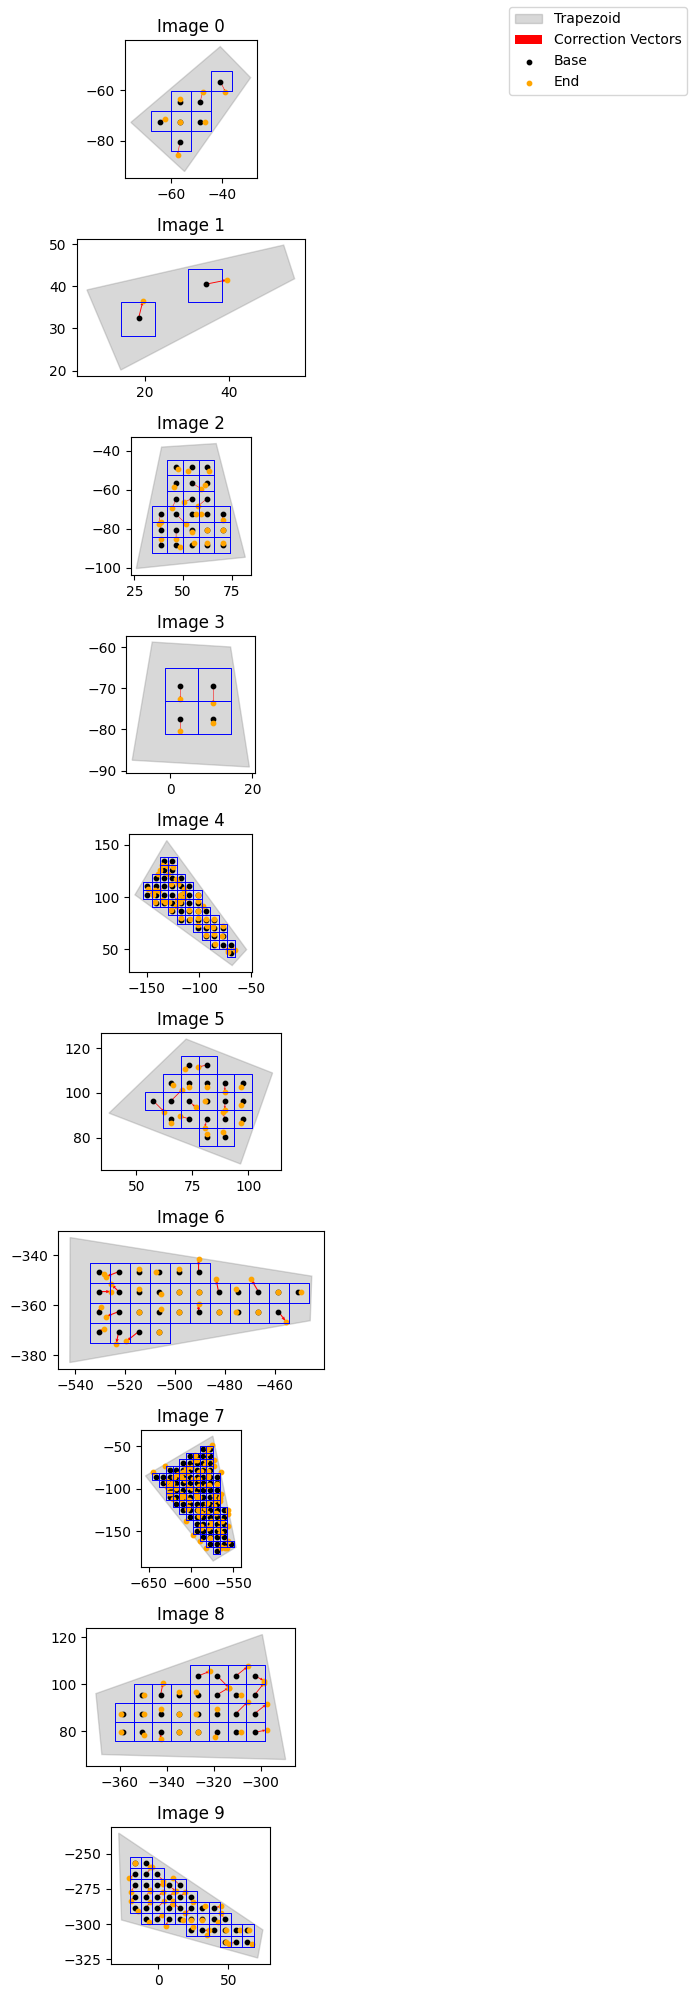

In [21]:
%matplotlib inline
mdb_plotter.plot_microps_w_corVecs()

In [22]:
# mdb_plotter.plot_distb_vecs(mpa.distb_vecs, mpa.full_mp_mean_var)

## 3. Softmax Function for SSD-Based Confidence

Given scores $s_1, s_2, \ldots, s_n$, the softmax function converts them into probabilities:

$$
p_i = \frac{\exp(s_i)}{\sum_j \exp(s_j)}
$$

Softmax: Larger scores receive exponentially more weight.

#### Applying Softmax to SSD Values

**lower SSD is better**, we convert SSD into softmax scores by negating them. We also subtract the minimum SSD value for numerical stability:

$$
p(\Delta x, \Delta y)
=
\frac{
    \exp\!\big(
        -\beta \big[
            \mathrm{SSD}(\Delta x, \Delta y)
            - \mathrm{SSD}_{\min}
        \big]
    \big)
}{
    \displaystyle
    \sum_{u=-5}^{5}
    \sum_{v=-5}^{5}
    \exp\!\big(
        -\beta \big[
            \mathrm{SSD}(u, v)
            - \mathrm{SSD}_{\min}
        \big]
    \big)
}
$$

Where:

- **SSD(Δx, Δy)**  
  The SSD value at shift $(\Delta x, \Delta y)$ in the 11×11 grid.

- **SSD_min**  
  The minimum SSD value (stability)

- **β (beta)**  
  A positive scalar controlling sharpness of the distribution.
  - Using 1/std of ssd values
  - Larger β: more peaked probabilities (higher confidence)  
  - Smaller β: flatter probabilities (lower confidence)

## Mean and std

This probabilistic representation allows computation of:

Mean shift vector:

$$
\mu
=
\begin{bmatrix}
\mu_x \\
\mu_y
\end{bmatrix}
=
\sum_{u=-5}^{5}
\sum_{v=-5}^{5}
p(u,v)
\begin{bmatrix}
u \\
v
\end{bmatrix}
$$

Covariance matrix:

$$
\Sigma
=
\sum_{u=-5}^{5}
\sum_{v=-5}^{5}
p(u,v)
\left(
\begin{bmatrix}
u \\
v
\end{bmatrix}
-
\mu
\right)
\left(
\begin{bmatrix}
u \\
v
\end{bmatrix}
-
\mu
\right)^{T}
$$

## Full patch softmax

In [23]:
# Through each patch and micro-patch, generate probability distb
mpa.prob_distb_FP = [{} for _ in range(gnav.im_num)]
mpa.ssds_curr_SM = [{} for _ in range(gnav.im_num)]
maxp = 0
# for imnum in range(gnav.im_num):
#     # Grab ssds - FOR FULL PATCH (WE SHOULD SAVE AND REPLUG THIS DATA *****)
#     # ssds = gnav.ssd_nxn(n_ssd, imnum)
#     ssds = gnav.ssd_nxn_NEW(n_ssd, imnum)
#     mpa.ssds_curr_SM[imnum] = ssds

In [24]:
# 'ssd_curr_SM_10IMG.pkl'
# 'ssd_curr_SM_10IMG_NEW.pkl'
# 'ssd_curr_SM_10IMG_NEW_noclip.pkl'

In [25]:
# # # Save SSDs for runtime help 
# # # Save data as pickle 
# fn = 'ssd_curr_SM_10IMG_NEW_noclip.pkl'
# with open(fn, 'wb') as f:
#     pickle.dump(mpa.ssds_curr_SM, f)

# Import pickle data structure so we do not have to run again
# Load
with open('ssd_curr_SM_10IMG_NEW_noclip.pkl', 'rb') as f:
    ssds_curr_SM_pkl = pickle.load(f)

# # Sanity check
# for imnum in range(len(gnav.images_dict)):
#     diff = mpa.ssds_curr_SM[imnum] - ssds_curr_SM_pkl[imnum]
#     print("DIFF", diff)

In [26]:
# Set to prev calculated
mpa.ssds_curr_SM = ssds_curr_SM_pkl
gnav.ssds_curr_SM = ssds_curr_SM_pkl

In [27]:
# Softmax distribution for each FULL patch - generates mpa.prob_distb_FP
mpa.FP_softmax()
# print(mpa.prob_distb_FP[0]['probs'])

## 4. Determining $P_i$


We define $P_i$ as the cumulative probability of all 'hypotheses' whose probability is greater than the ground-truth hypothesis at the $(0,0)$ shift, or $P_{\mathrm{GT}}$.



$$
P_{\mathrm{GT}} \;=\; p(0,0)
$$

$$
P_i \;=\; \sum_{(\Delta x,\Delta y)\in \mathcal{S}_i} p(\Delta x,\Delta y)
$$

$$
\mathcal{S}_i \;=\; \left\{(\Delta x,\Delta y)\;:\; p(\Delta x,\Delta y) > P_{\mathrm{GT}} \right\}
$$


STEPS
- [x] Visualize surface plot of probabilities with $(0,0)$ marked
- [x] Determine probabilities greater than $P_{GT}$
- [x] Sum these probabilities - THE $X$-axis, $P_i$
- [x] calculate CDF of probs (amount of probabilities over $P_{GT}$) - THE $Y$-axis
- [x] Plot results

In [28]:
# Surface plot visualization 
%matplotlib qt
# %matplotlib inline
imnum = 1
probs = mpa.prob_distb_FP[imnum]['probs']
mdb_plotter.ssd_surface_plots(probs, imnum, n_ssd, method='probs')

Highest probability shift for image 1: 0 -1


In [29]:
# Set ground truth
p = mpa.im_num
gt = [0,0]
idrow, idcol = gt[0] + n_ssd, gt[1] + n_ssd
Pi_p = np.zeros((p))
cdf = np.zeros((p))
l_total = (n_ssd*2 + 1)**2
print("ID of row and col for P_GT:", idrow, idcol)
# Determine P_i for each image 
for imnum in range(mpa.im_num):
    probs = mpa.prob_distb_FP[imnum]['probs']
    pgt = probs[idrow, idcol]
    # print("Probabilities\n", probs)
    print("\nProbability of ground truth:", pgt)
    mask = probs > pgt
    # print("\nMask of probabilities:\n",mask)
    probs_p_ind = np.argwhere(probs > pgt)
    # print("\nProbs over PGT (indices):\n", probs_p_ind)
    probs_p = probs[mask]
    l_probs = len(probs_p)
    print(f"\nProbs over PGT, length {l_probs}:\n", probs_p)
    P_i = np.sum(probs_p)
    print("\nP_i:", P_i)
    print("\nCDF:", l_probs/l_total)
    Pi_p[imnum] = P_i
    cdf[imnum] = l_probs / l_total

print("\nFINAL P_i's: \n", Pi_p)

ID of row and col for P_GT: 5 5

Probability of ground truth: 0.03287461357432116

Probs over PGT, length 5:
 [0.03597161 0.0433046  0.0453763  0.03813331 0.03320302]

P_i: 0.19598883822334168

CDF: 0.04132231404958678

Probability of ground truth: 0.029405117037247346

Probs over PGT, length 5:
 [0.03059767 0.0313412  0.02995346 0.03116484 0.03358416]

P_i: 0.15664133273382652

CDF: 0.04132231404958678

Probability of ground truth: 0.040108995215760154

Probs over PGT, length 0:
 []

P_i: 0.0

CDF: 0.0

Probability of ground truth: 0.02520773485531593

Probs over PGT, length 8:
 [0.02549741 0.03081722 0.03733662 0.04188107 0.04282788 0.0364367
 0.03272061 0.02904582]

P_i: 0.2765633455445847

CDF: 0.06611570247933884

Probability of ground truth: 0.04722616695613887

Probs over PGT, length 2:
 [0.06275688 0.05466029]

P_i: 0.11741716697442514

CDF: 0.01652892561983471

Probability of ground truth: 0.0238490335854529

Probs over PGT, length 7:
 [0.03096888 0.04113992 0.04021529 0.02914

### Plot description

- The x-axis shows our calculated $P_i$ for each patch (image).
    - This is the sum of the probabilities that are greater than the probability of the ground truth $P_{GT}$ at $(0,0)$
- The y-axis shows probability that this actually occured (the number of measurements over the total number of measurements)
- A $y=x$ line is shown as a reference
    - Thus, curves above the line show that the probability occured more frequently than predicted (overconfident)
    - Curves below the line show that the probability occured less frquently than predicted - (underconfident)

Overall: need more data

In [30]:
# PLOT 
Pi_ind_p = np.argsort(Pi_p)
# print(Pi_ind_p)
Pi_p_sorted = Pi_p[Pi_ind_p]
cdf_sorted = cdf[Pi_ind_p]

N = len(Pi_p)
cdf_new = np.linspace(0,len(Pi_p_sorted)-1, len(Pi_p_sorted))/len(Pi_p_sorted)
cdf_new = np.arange(1,N+1)/N
print(cdf_new)




# ---- Plot ----
plt.figure(figsize=(6, 5))
# OLD
# plt.plot(Pi_p_sorted, cdf_sorted, linewidth=2, label="Empirical CDF of $P_i$")
# plt.scatter(Pi_p_sorted, cdf_sorted, c='blue')
# NEW
plt.plot(Pi_p_sorted, cdf_new, linewidth=2, label="Empirical CDF of $P_i$")
plt.scatter(Pi_p_sorted, cdf_new, c='blue')
plt.plot([0, 1], [0, 1], "--", linewidth=2, label="Reference: $y=x$")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("$P_i$: PDF")
plt.ylabel("CDF")
plt.title("Empirical CDF of $P_i$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [32]:
print(mpa.prob_distb_FP[1])

{'mu': array([-0.64492306, -1.43301151]), 'cov': array([[ 5.85636927, -0.84706609],
       [-0.84706609,  7.47443032]]), 'probs': array([[0.0103466 , 0.00998089, 0.00921954, 0.00843244, 0.00795372,
        0.0072034 , 0.00657736, 0.00638806, 0.00523089, 0.00426887,
        0.00380996],
       [0.01004737, 0.00948251, 0.00858106, 0.00818184, 0.00743587,
        0.00677065, 0.00642785, 0.0052273 , 0.00454358, 0.00410912,
        0.00365846],
       [0.00970309, 0.0091542 , 0.00844076, 0.00780368, 0.00712028,
        0.00661808, 0.00559082, 0.004568  , 0.00408514, 0.00331278,
        0.00262154],
       [0.01268171, 0.01177027, 0.01100318, 0.01113261, 0.01035498,
        0.00851099, 0.00695185, 0.00544116, 0.00395812, 0.00281204,
        0.00221812],
       [0.02313313, 0.02266266, 0.02227429, 0.02345971, 0.02224816,
        0.020808  , 0.01572613, 0.01081781, 0.00725492, 0.00517565,
        0.0039769 ],
       [0.03059767, 0.0313412 , 0.02995346, 0.03116484, 0.03358416,
        0.0294051

# Micropatch calibration analysis

Representing the error probability for the state estimation of an image patch, through a series of micropatch estimations

Each patch $X_i$ is made up of $n$ micropatches 

The probability of the ground truth $P_{GT}$ is the probability of the a patch measurment at $(0,0)$

The probability measure encompassing ground truth for each patch is $P_{MG}$

$$
P_{MG}(x) \;=\; \frac{1}{n} \sum_{n=1}^{n} norm.pdf(x_i : \mu_i, cov_i)
$$

4 Step process:

1.  Micropatch 2D errors - blur with gaussianc
2.  Continuous pdf from mixture of gaussians
3.  discrete distribution - sample pdf on SSD grid (and normalize samples to sum to 1)
4.  Watershed to ground truth @ 0 (as for softmax process)

ASSUMPTIONS:
- blurring function - setting at 3 pixel $\sigma$
- grid resolution in step 3 - will run a test for reliability

STEPS:
- [x] Obtain error vectors from mps
- [x] Create continuous pdf from mixture of blurred gaussians
- [ ] VERIFICATION
- [x] Sample discrete distribution
- [x] normalize
- [x] Watershed to ground truth
- [x] Sort
- [x] Plot!

In [33]:
mdb_plotter.plot_distb_vecs(mpa.distb_vecs, mpa.full_mp_mean_var)

In [34]:
# Probability distribution generated FOR the full patch BY the micropatch process 
mpa.prob_distb_MP = [{} for i in range(mpa.im_num)]
print(mpa.prob_distb_MP)

[{}, {}, {}, {}, {}, {}, {}, {}, {}, {}]


In [35]:
mpa.exclusion_dirs()

Total micropatches: 296
Micropatches with less than 2 confidence directions: 275
Micropatches with less than NO confidence directions: 17


In [36]:
c = 0
for i in range(10):
    print(len(gnav.micro_ps[i]))
    for mp in range(len(gnav.micro_ps[i])):
        cdirs = mpa.sm_distb_conf[i][mp]['cdirs']
        # print(cdirs)
print(mpa.sm_distb_conf[0][1])
# print(len(gnav.micro_ps[0]))

7
2
24
4
48
20
31
92
27
41
{'mu': array([-1.42908235, -0.64986967]), 'cov': array([[5.01636737, 0.57171866],
       [0.57171866, 9.05176357]]), 'cdirs': 1, 'eigvals': array([4.93693222, 9.13119872]), 'eigvecs': array([[-0.99048524,  0.13761898],
       [ 0.13761898,  0.99048524]])}


In [37]:
def cont_pdf_gblur(x, distb_vecs, sigma_pix):
    assert distb_vecs.ndim == 2 and distb_vecs.shape[1] == 2
    cov = np.eye(2) * (sigma_pix**2)
    vals = [multivariate_normal.pdf(x, mean=mu, cov = cov) for mu in distb_vecs]
    return np.mean(vals)

In [38]:
def cont_pdf_gblur_aniso(imnum, x, distb_vecs):
    """
    Anisotropic Gaussian blur using discrete confidence directions
    
    Inputs:
        imnum       : image index
        x           : (2,) query point
        distb_vecs  : (num_mp, 2) mean shifts
    
    Output:
        scalar probability
    """

    vals = []

    for mp, mu in enumerate(distb_vecs):
        conf = mpa.sm_distb_conf[imnum][mp]

        cdirs = conf['cdirs']
        eigvecs = conf['eigvecs']  # [v_small, v_large]

        # Build eigenvector matrix (columns)
        V = np.column_stack((eigvecs[0], eigvecs[1]))

        # --- Define blur ---
        if cdirs == 2:
            sigma_small = 3
            sigma_large = 3

        elif cdirs == 1:
            sigma_small = 1 #2   # confident direction
            sigma_large = 2 #4   # unconfident direction

        else:  # cdirs == 0
            # Option 1: skip (recommended)
            continue

            # Option 2 (alternative):
            # sigma_small = 9
            # sigma_large = 9

        # --- Build covariance ---
        Lambda = np.diag([sigma_small**2, sigma_large**2])
        cov = V @ Lambda @ V.T

        # --- Evaluate Gaussian ---
        vals.append(multivariate_normal.pdf(x, mean=mu, cov=cov))

    # Avoid empty case
    if len(vals) == 0:
        return 0.0

    return np.mean(vals)

In [39]:
def cont_pdf_gblur_aniso_PTEST(imnum, x, distb_vecs, sL, sS):
    """
    Anisotropic Gaussian blur using discrete confidence directions
    
    Inputs:
        imnum       : image index
        x           : (2,) query point
        distb_vecs  : (num_mp, 2) mean shifts
    
    Output:
        scalar probability
    """

    vals = []

    for mp, mu in enumerate(distb_vecs):
        conf = mpa.sm_distb_conf[imnum][mp]

        cdirs = conf['cdirs']
        eigvecs = conf['eigvecs']  # [v_small, v_large]

        # Build eigenvector matrix (columns)
        V = np.column_stack((eigvecs[0], eigvecs[1]))

        # --- Define blur ---
        if cdirs == 2:
            sigma_small = sS # sS # sL # 3
            sigma_large = sS # sS # sL # 3

        elif cdirs == 1:
            sigma_small = sS #2   # confident direction
            sigma_large = sL #4   # unconfident direction

        else:  # cdirs == 0
            # Option 1: skip (recommended)
            continue

            # Option 2 (alternative):
            # sigma_small = 9
            # sigma_large = 9

        # --- Build covariance ---
        Lambda = np.diag([sigma_small**2, sigma_large**2])
        cov = V @ Lambda @ V.T

        # --- Evaluate Gaussian ---
        vals.append(multivariate_normal.pdf(x, mean=mu, cov=cov))

    # Avoid empty case
    if len(vals) == 0:
        return 0.0

    return np.mean(vals)

In [40]:
# REGULAR PROBABILITY CALCS
# =====================
# Define variables
n_ssd = 5 # SSD full shift 
sigma_pix = 3 # Gaussian blur param
GT_pos = np.array([0,0]) # Position of ground truth
Pi_p_microp = np.zeros((mpa.im_num)) # eCDF probabilities
step = 1 # Grid size 
steps_TEST = [.05, 1, 25, .5, 1] 
Pi_p_microp_GRID_TEST = []
shifts = np.arange(-n_ssd, n_ssd+step, step) 
print(f'Shifts: {shifts}')
N = len(shifts)
# SIGMA LARGE AND SIGMA SMALL
sL = 2
sS = 1


# print(GT_pos.shape)
for imnum in range(mpa.im_num):
    distb_vecs_im = mpa.distb_vecs[imnum]
    # LOOP OVER SSD 
    # ssds_prob = np.zeros((2*n_ssd + 1, 2*n_ssd + 1))
    ssds_prob = np.zeros((N,N))
    ssds_prob_ani = np.zeros((N,N))
    count = 0
    for i, xshift in enumerate(shifts):
        for j, yshift in enumerate(shifts):
            count +=1
            shift = np.array([xshift, yshift])
            # print("SSD shift:", xshift, yshift)
            p_x = cont_pdf_gblur(shift, distb_vecs_im, sigma_pix)
            p_x_ani = cont_pdf_gblur_aniso(imnum, shift, distb_vecs_im)
            # print("P_x:", p_x)
            # ssds_prob[xind,yind] = p_x
            ssds_prob[i,j] = p_x
            ssds_prob_ani[i,j] = p_x_ani

    # Normalize and place probabilities in dict and 
    # print(f"Discrete probabilites for image {imnum}: \n{ssds_prob}")
    # sum_probs = np.sum(ssds_prob)
    sum_probs = np.sum(ssds_prob_ani)
    # print("SUM of probabilities:", sum_probs)
    # norm_probs = ssds_prob / sum_probs
    norm_probs = ssds_prob_ani / sum_probs
    mpa.prob_distb_MP[imnum]['probs'] = norm_probs
    # print("Normalized probabilities:", norm_probs)

    # Watershed for gt
    ix = np.argmin(np.abs(shifts - GT_pos[0]))
    iy = np.argmin(np.abs(shifts - GT_pos[1]))
    # pgt = norm_probs[n_ssd, n_ssd] # Ground truth probability
    pgt = norm_probs[ix,iy]
    # print(f'Ground truth probability indices: {ix,iy}')
    # print(f'Ground truth probability: {pgt}')
    mask = norm_probs >= pgt
    probs_over_gt = norm_probs[mask]
    l_probs = len(probs_over_gt)
    # print(f"\nProbs over PGT, length {l_probs}:\n", np.round(probs_over_gt,4))
    P_i = np.sum(probs_over_gt)
    print('\nP_i: %.3f' % P_i)
    Pi_p_microp[imnum] = P_i

print(f"\nFINAL P_i's: {Pi_p_microp}")
Pi_p_microp_INITIAL = Pi_p_microp


Shifts: [-5 -4 -3 -2 -1  0  1  2  3  4  5]

P_i: 0.068

P_i: 0.931

P_i: 0.109

P_i: 0.651

P_i: 0.164

P_i: 0.370

P_i: 0.042

P_i: 0.791

P_i: 0.039

P_i: 0.201

FINAL P_i's: [0.06806297 0.93070493 0.10873966 0.65059461 0.16386318 0.36977063
 0.04161536 0.79075046 0.0393814  0.20142944]


In [41]:
# CALCS FOR PARAM TUNING 
# =====================
# Define variables
n_ssd = 5 # SSD full shift 
sigma_pix = 3 # Gaussian blur param
GT_pos = np.array([0,0]) # Position of ground truth
Pi_p_microp = np.zeros((mpa.im_num)) # eCDF probabilities
step = 1 # Grid size 
steps_TEST = [.05, 1, 25, .5, 1] 
Pi_p_microp_GRID_TEST = []
shifts = np.arange(-n_ssd, n_ssd+step, step) 
print(f'Shifts: {shifts}')
N = len(shifts)
# SIGMA LARGE AND SIGMA SMALL
sL = 2
sS = 1

Pi_p_microp_PARAM_T = []
# REMOVING: [8,4], [6,4], [4,3], [3,2], [6,3], [4,2], [3,1], 
params_to_test = np.array([[2,1], [1, 0.5], [0.75, 0.25]])

for params in params_to_test:
    print(f"Testing params (sigma_large, sigma_small): {params}")
    Pi_p_microp = np.zeros(mpa.im_num)
    # print(GT_pos.shape)
    for imnum in range(mpa.im_num):
        distb_vecs_im = mpa.distb_vecs[imnum]
        # LOOP OVER SSD 
        # ssds_prob = np.zeros((2*n_ssd + 1, 2*n_ssd + 1))
        ssds_prob = np.zeros((N,N))
        ssds_prob_ani = np.zeros((N,N))
        count = 0
        for i, xshift in enumerate(shifts):
            for j, yshift in enumerate(shifts):
                count +=1
                shift = np.array([xshift, yshift])
                # print("SSD shift:", xshift, yshift)
                p_x = cont_pdf_gblur(shift, distb_vecs_im, sigma_pix)
                p_x_ani = cont_pdf_gblur_aniso_PTEST(imnum, shift, distb_vecs_im, params[0], params[1])
                # print("P_x:", p_x)
                # ssds_prob[xind,yind] = p_x
                ssds_prob[i,j] = p_x
                ssds_prob_ani[i,j] = p_x_ani
    
        # Normalize and place probabilities in dict and 
        # print(f"Discrete probabilites for image {imnum}: \n{ssds_prob}")
        # sum_probs = np.sum(ssds_prob)
        sum_probs = np.sum(ssds_prob_ani)
        # print("SUM of probabilities:", sum_probs)
        # norm_probs = ssds_prob / sum_probs
        norm_probs = ssds_prob_ani / sum_probs
        mpa.prob_distb_MP[imnum]['probs'] = norm_probs
        # print("Normalized probabilities:", norm_probs)
    
        # Watershed for gt
        ix = np.argmin(np.abs(shifts - GT_pos[0]))
        iy = np.argmin(np.abs(shifts - GT_pos[1]))
        # pgt = norm_probs[n_ssd, n_ssd] # Ground truth probability
        pgt = norm_probs[ix,iy]
        # print(f'Ground truth probability indices: {ix,iy}')
        # print(f'Ground truth probability: {pgt}')
        mask = norm_probs >= pgt
        probs_over_gt = norm_probs[mask]
        l_probs = len(probs_over_gt)
        # print(f"\nProbs over PGT, length {l_probs}:\n", np.round(probs_over_gt,4))
        P_i = np.sum(probs_over_gt)
        # print('\nP_i: %.3f' % P_i)
        Pi_p_microp[imnum] = P_i
    
    print(f"\nFINAL P_i's: {Pi_p_microp}")
    # Pi_p_microp_INITIAL = Pi_p_microp
    Pi_p_microp_PARAM_T.append(Pi_p_microp.copy())


Shifts: [-5 -4 -3 -2 -1  0  1  2  3  4  5]
Testing params (sigma_large, sigma_small): [2. 1.]

FINAL P_i's: [0.06806297 0.93070493 0.08018174 0.65059461 0.15558945 0.40070236
 0.05163532 0.79075046 0.04277363 0.08864066]
Testing params (sigma_large, sigma_small): [1.  0.5]

FINAL P_i's: [0.17873181 0.99999279 0.06763255 0.7250457  0.37292348 0.73355069
 0.12691409 0.77535586 0.07394879 0.11779607]
Testing params (sigma_large, sigma_small): [0.75 0.25]

FINAL P_i's: [0.26665004 1.         0.11444089 0.97406895 0.5300106  0.93905925
 0.19848369 0.84357756 0.31549016 0.41884962]


In [42]:
# # Surface plot visualization 
# %matplotlib qt
# # %matplotlib inline
# imnum = 0
# probs = mpa.prob_distb_MP[imnum]['probs']
# mdb_plotter.ssd_surface_plots(probs, imnum, n_ssd, method='probs')

In [43]:
# mdb_plotter.compare_iso_ani_surface(ssds_prob, ssds_prob_ani, imnum, n_ssd)

In [44]:
# # PLOT 
# N1 = len(Pi_p)
# Pi_p_sorted = np.sort(Pi_p)
# cdf1 = np.arange(1,N1+1)/N1
# # cdf1 = np.arange(0,N1)/N1

# # SECOND PLOT 
# N2 = len(Pi_p_microp_INITIAL)
# Pi_p_microp_sorted = np.sort(Pi_p_microp_INITIAL)
# cdf2 = np.arange(1,N2+1)/N2
# print(Pi_p_microp_sorted)
# print(f"Micropatch PDF probabilities: \n{np.round(Pi_p_microp_sorted,3)}")
# # cdf2 = np.arange(0,N2)/N2

# # ---- Plot ----
# plt.figure(figsize=(6, 5))
# # NEW
# plt.plot(Pi_p_sorted, cdf1, linewidth=2, label="eCDF of $P_i$ (Softmax)")
# plt.scatter(Pi_p_sorted, cdf1, c='blue')
# plt.plot(Pi_p_microp_sorted, cdf2, linewidth=2, label="eCDF of $P_i$ (micropatches)")
# plt.scatter(Pi_p_microp_sorted, cdf2, c='orange')
# plt.plot([0, 1], [0, 1], "--", linewidth=2, label="Reference: $y=x$")

# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.xlabel("$P_i$: PDF")
# plt.ylabel("CDF")
# plt.title("Empirical CDF of $P_i$")
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

In [45]:
# ========= SIGMA DEPENDENCY =============
# ---- Baseline (softmax) eCDF ----
Pi_p_sorted = np.sort(Pi_p)
N1 = len(Pi_p_sorted)
cdf1 = np.arange(1, N1 + 1) / N1

plt.figure(figsize=(6, 5))

plt.plot(Pi_p_sorted, cdf1, linewidth=2, label="eCDF of $P_i$ (Softmax)")
plt.scatter(Pi_p_sorted, cdf1, s=15)  # no fixed color

# ---- Micropatch grid-dependency eCDFs ----
for sigma, Pi_sigma in zip(params_to_test, Pi_p_microp_PARAM_T):
    Pi_sigma_sorted = np.sort(Pi_sigma)
    N = len(Pi_sigma_sorted)
    cdf = np.arange(1, N + 1) / N

    # if sigma == 1:# or sigma == 3:
        # plt.plot(Pi_sigma_sorted, cdf, linewidth=2, label=f"micropatches ($\sigma$={sigma})")
        # plt.scatter(Pi_step_sorted, cdf, s=10)
        
    plt.plot(Pi_sigma_sorted, cdf, linewidth=2, label=f"micropatches ($\sigma$={sigma})")
    # optional scatter if you want it:
    plt.scatter(Pi_sigma_sorted, cdf, s=10)

# Reference line
plt.plot([0, 1], [0, 1], "--", linewidth=2, label="Reference: $y=x$")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("$P_i$")
plt.ylabel("CDF")
# plt.title("$\sigma$ Dependency: Empirical CDF of $P_i$")
# plt.title("Empirical CDF of $P_i$")
plt.grid(True, alpha=0.3)
# plt.legend()
plt.legend(
    fontsize=9,
    labelspacing=0.3,
    borderpad=0.4,
    handlelength=1.5
)
plt.tight_layout()
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5197/1520394245.py:22: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(Pi_sigma_sorted, cdf, linewidth=2, label=f"micropatches ($\sigma$={sigma})")
